# 1. Introduction

The objective of this notebook is to evaluate multiple modeling approaches for forecasting future market volatility.

We compare:  
- Linear benchmark models
- Econometric volatility models
- Machine learning models  

All models are evaluated using a strict chronological split to avoid look-ahead bias.

# 2. Experimental Setup  
## 2.1 Data Partitioning

The dataset was chronologically split into three distinct periods:

- Training set (2000–2016) → Model estimation
- Validation set (2017–2019) → Hyperparameter tuning
- Test set (2020–2025) → Final out-of-sample evaluation

This time-based split ensures:

- No look-ahead bias
- Realistic forward performance
- Fair model comparison across experiments

The split is fixed and reused consistently throughout the modeling process.

In [1]:
import joblib

X_train_red = joblib.load("../models/X_train_red.pkl")
X_val_red   = joblib.load("../models/X_val_red.pkl")
X_test_red  = joblib.load("../models/X_test_red.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_val   = joblib.load("../models/y_val.pkl")
y_test  = joblib.load("../models/y_test.pkl")

from pathlib import Path

# create outputs folder if it does not exist
Path("../outputs").mkdir(exist_ok=True)

## 2.2 Evaluation Metrics

We evaluate models using:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² (Coefficient of Determination)

RMSE penalizes large volatility errors more heavily, which is desirable in financial applications.

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

The experimental framework is intentionally conservative and forward-looking.

By enforcing:  
A fixed chronological split  
Proper scaling discipline  
Multi-metric evaluation  
we ensure that model comparisons are reliable, reproducible, and financially meaningful.  
  
This foundation allows us to objectively compare linear, tree-based, and advanced models in the following sections.

# 3. Baseline & Econometric Models  
## 3.1 OLS Regression

We first estimate a simple linear regression model to establish a baseline.  
This model assumes a linear relationship between engineered features and future volatility.

In [3]:
from sklearn.linear_model import LinearRegression

# Initialize model
ols = LinearRegression()

# Fit on training data
ols.fit(X_train_red, y_train)

# Validation predictions
y_val_pred_ols = ols.predict(X_val_red)

# Evaluate
metrics_ols = evaluate_model(y_val, y_val_pred_ols)

metrics_ols

{'RMSE': np.float64(0.528669389278653),
 'MAE': 0.41607401646811326,
 'R2': 0.3174107643599412}

OLS serves as:

. A variance-uncontrolled linear benchmark  
. A diagnostic tool for feature signal  
. A baseline to assess the value of regularization  

If more complex models do not significantly outperform OLS, their added complexity may not be justified.

## 3.2 Ridge Regression

Ridge regression introduces L2 regularization to mitigate multicollinearity and reduce variance.

This is particularly relevant given the presence of correlated volatility features.

In [4]:
from sklearn.linear_model import Ridge

# Initialize model
ridge = Ridge(alpha=1.0)

# Fit
ridge.fit(X_train_red, y_train)

# Validation predictions
y_val_pred_ridge = ridge.predict(X_val_red)

# Evaluate
metrics_ridge = evaluate_model(y_val, y_val_pred_ridge)

metrics_ridge

c:\Users\romai\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.41167e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


{'RMSE': np.float64(0.6152880537475518),
 'MAE': 0.4939656749022799,
 'R2': 0.07541238524940808}

Why Ridge Matters Here  
  
. Financial features often exhibit:  
. High correlation  
. Persistent dynamics  
. Overlapping rolling statistics  
  
Ridge helps reduce variance while preserving explanatory structure.  
If Ridge significantly outperforms OLS, it suggests multicollinearity is impacting model stability.

## 3.3 GARCH(1,1) Benchmark

We implement a GARCH(1,1) model as an econometric benchmark.  
GARCH models are specifically designed to capture:  
. Volatility clustering  
. Conditional heteroskedasticity  
. Persistence dynamics  
  
This provides a financially meaningful reference point.  
Unlike ML models, GARCH directly models conditional variance dynamics.

In [5]:
%pip install arch

Note: you may need to restart the kernel to use updated packages.


In [6]:
from arch import arch_model

# Fit GARCH(1,1) on training target
garch = arch_model(y_train, vol='Garch', p=1, q=1)
garch_fit = garch.fit(disp='off')

# Forecast on validation horizon
garch_forecast = garch_fit.forecast(horizon=len(y_val))

# Extract predicted variance
garch_var = garch_forecast.variance.values[-1]

# Convert to comparable scale if needed
y_val_pred_garch = garch_var

# Evaluate
metrics_garch = evaluate_model(y_val, y_val_pred_garch)

metrics_garch

{'RMSE': np.float64(4.829367275667472),
 'MAE': 4.786905861589236,
 'R2': -55.960209165977275}

In [7]:
import pandas as pd

comparison_df = pd.DataFrame({
    "OLS": metrics_ols,
    "Ridge": metrics_ridge,
    "GARCH(1,1)": metrics_garch
}).T

comparison_df.round(6)

,RMSE,MAE,R2
OLS,0.528669,0.416074,0.317411
Ridge,0.615288,0.493966,0.075412
"GARCH(1,1)",4.829367,4.786906,-55.960209


OLS delivers the strongest performance on the validation set, achieving a meaningful R² (~0.32).

Ridge underperforms, suggesting that regularization is not necessary in the current feature space.

GARCH(1,1) performs substantially worse, indicating that volatility persistence alone is insufficient during this period.

Overall, feature-based linear modeling already captures relevant predictive structure, providing a solid benchmark for the upcoming non-linear models.

# 4. Machine Learning Models  
After establishing linear and econometric benchmarks, we now evaluate non-linear machine learning models.

These models are designed to capture:
- Non-linear dependencies
- Interaction effects between features
- Regime-dependent volatility patterns

All evaluations are conducted on the validation set.

## 4.1 Random Forest  
Random Forest captures:
- Non-linear relationships
- Interaction effects
- Regime-dependent patterns

It is robust to multicollinearity and feature scaling.

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Fit
rf.fit(X_train_red, y_train)

# Validation predictions
y_val_pred_rf = rf.predict(X_val_red)

# Evaluate
metrics_rf = evaluate_model(y_val, y_val_pred_rf)

metrics_rf

{'RMSE': np.float64(0.5081987554706143),
 'MAE': 0.3878155120394394,
 'R2': 0.3692484885899757}

## 4.2 Gradient Boosting (XGBoost)  
Gradient Boosting models sequentially correct previous errors.

They are particularly effective for:
- Structured tabular data
- Non-linear volatility dynamics
- Feature interaction learning
  
Boosting methods often outperform bagging methods (like Random Forest) in tabular financial datasets.

In [9]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [10]:
from xgboost import XGBRegressor

# Initialize model
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit
xgb.fit(X_train_red, y_train)

# Validation predictions
y_val_pred_xgb = xgb.predict(X_val_red)

# Evaluate
metrics_xgb = evaluate_model(y_val, y_val_pred_xgb)

metrics_xgb

{'RMSE': np.float64(0.6062035534429883),
 'MAE': 0.4668442375686105,
 'R2': 0.10251321803780877}

In [11]:
comparison_ml = pd.DataFrame({
    "OLS": metrics_ols,
    "Ridge": metrics_ridge,
    "Random Forest": metrics_rf,
    "XGBoost": metrics_xgb
}).T

comparison_ml.round(6)

,RMSE,MAE,R2
OLS,0.528669,0.416074,0.317411
Ridge,0.615288,0.493966,0.075412
Random Forest,0.508199,0.387816,0.369248
XGBoost,0.606204,0.466844,0.102513


Random Forest achieves the best validation performance, improving both RMSE and R² over OLS. This indicates that non-linear effects and feature interactions contribute meaningfully to volatility prediction.

XGBoost, however, underperforms in its current configuration, suggesting suboptimal hyperparameters rather than structural weakness.

Overall, the results confirm that volatility dynamics are not purely linear, and that flexible tree-based models provide incremental predictive value over baseline regressions.

# 5. Hyperparameter Tuning
After identifying Random Forest as the strongest model on the validation set, we refine its performance through structured hyperparameter optimization.  
Given the temporal nature of the data, standard cross-validation is inappropriate.  
Instead, we use expanding-window cross-validation via TimeSeriesSplit to ensure:  

* No look-ahead bias
* Chronological integrity
* Robust performance estimation

## 5.1 Time-Series Cross-Validation
We use TimeSeriesSplit with 5 folds.

This configuration provides several out-of-sample evaluation windows
while keeping sufficiently large training sets for stable estimation.

Additional tests with 3 and 8 folds produced similar results, suggesting
that model performance is not highly sensitive to the exact number of splits.

In [12]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_red)):
    print(f"Fold {fold+1}")
    print("Train size:", len(train_idx))
    print("Validation size:", len(val_idx))
    print("-" * 30)

Fold 1
Train size: 693
Validation size: 693
------------------------------
Fold 2
Train size: 1386
Validation size: 693
------------------------------
Fold 3
Train size: 2079
Validation size: 693
------------------------------
Fold 4
Train size: 2772
Validation size: 693
------------------------------
Fold 5
Train size: 3465
Validation size: 693
------------------------------


## 5.2 Grid Search Optimization

Hyperparameters are tuned using GridSearchCV combined with TimeSeriesSplit.

The optimization objective is minimizing validation RMSE.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400, 600], # Number of trees in the forest
    "max_depth": [None, 5, 10],      # Tree complexity
    "min_samples_split": [2, 5, 10], # Regularization to prevent overfitting
    "max_features": ["sqrt", 0.8]    # Number of features to consider at each split
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_red, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 400, 600]},
             scoring='neg_root_mean_squared_error', verbose=1)

## 5.3 Best Model Selection

In [14]:
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}

Best CV RMSE:
0.44643129874064186


In [15]:
y_val_pred_rf_tuned = best_rf.predict(X_val_red)

metrics_rf_tuned = evaluate_model(y_val, y_val_pred_rf_tuned)

metrics_rf_tuned

{'RMSE': np.float64(0.49186706700922217),
 'MAE': 0.3714441509866552,
 'R2': 0.4091372708091937}

In [16]:
comparison_rf = pd.DataFrame({
    "Random Forest": metrics_rf,
    "RF (Tuned)": metrics_rf_tuned
}).T

comparison_rf.round(6)

,RMSE,MAE,R2
Random Forest,0.508199,0.387816,0.369248
RF (Tuned),0.491867,0.371444,0.409137


Hyperparameter tuning slightly improves model performance.  
This suggests that the default Random Forest configuration was already reasonably well suited for the problem, but tuning allows better control of model complexity and variance.

The tuned model will therefore be retained for the final evaluation.

# 6. Model Evaluation  

This section evaluates model performance using a strict out-of-sample framework.

Model comparison is first conducted on the validation dataset to select the best candidate models.
Final performance is then assessed on the test dataset, which remains untouched during training and hyperparameter tuning.

Beyond aggregate metrics, we also analyze:

* Predicted vs realized volatility
* Residual diagnostics
* Performance stability across time

This provides a more comprehensive understanding of model robustness across different market regimes.

## 6.1 Model Comparison
We first compare model performance on the validation set.  
This dataset is used exclusively for model selection, ensuring that the test set remains unbiased.

In [17]:
results_val = {}

models = {
    "OLS": ols,
    "Ridge": ridge,
    "Random Forest": best_rf,
    "XGBoost": xgb
}

for name, model in models.items():
    
    preds = model.predict(X_val_red)
    
    results_val[name] = evaluate_model(y_val, preds)


results_val = pd.DataFrame(results_val).T
results_val.round(6)

,RMSE,MAE,R2
OLS,0.528669,0.416074,0.317411
Ridge,0.615288,0.493966,0.075412
Random Forest,0.491867,0.371444,0.409137
XGBoost,0.606204,0.466844,0.102513


This table allows us to compare models based on RMSE, MAE and R² before evaluating final performance.

## 6.2 Final Out-of-Sample Performance

After selecting the most promising models, we evaluate them on the test dataset.

In [18]:
results_test = {}

for name, model in models.items():
    
    preds = model.predict(X_test_red)
    
    results_test[name] = evaluate_model(y_test, preds)


results_test = pd.DataFrame(results_test).T
results_test.round(6)

,RMSE,MAE,R2
OLS,0.951642,0.832335,-1.624560
Ridge,1.541092,1.411979,-5.882816
Random Forest,0.453840,0.347203,0.403083
XGBoost,0.614988,0.502466,-0.096078


The test set provides an unbiased estimate of real-world performance.

## 6.3 Predicted vs Actual Volatility

We visualize predicted volatility against realized volatility to evaluate:
* Tracking ability
* Sensitivity to volatility spikes
* Potential underestimation during crisis regimes

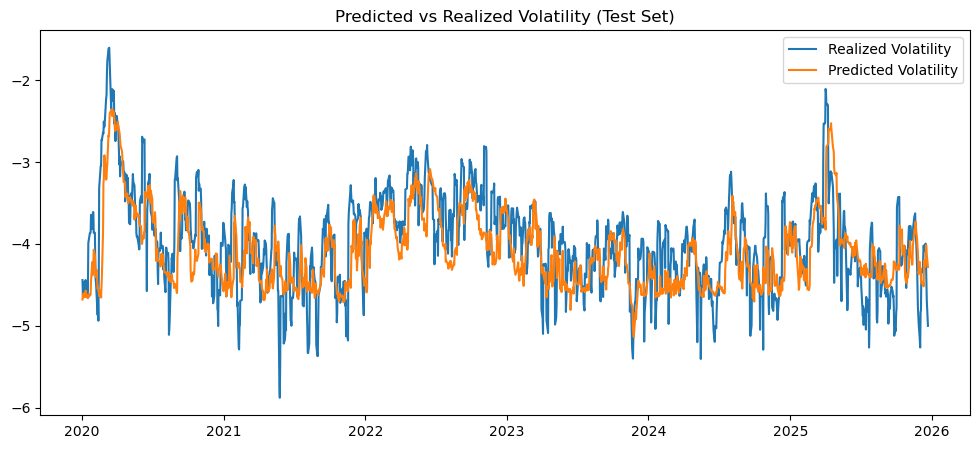

In [19]:
import matplotlib.pyplot as plt

best_model = best_rf

y_pred_test = best_model.predict(X_test_red)

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Realized Volatility")
plt.plot(y_test.index, y_pred_test, label="Predicted Volatility")

plt.title("Predicted vs Realized Volatility (Test Set)")
plt.legend()

plt.show()

Predicted volatility broadly tracks realized volatility, indicating that the model captures the main dynamics of market risk.  
However, extreme volatility spikes are partially underestimated, a common limitation of statistical volatility models.
  
Overall, the model captures regime shifts reasonably well while smoothing the most abrupt market shocks.


## 6.4 Residual Diagnostics

Residual analysis helps detect:
* systematic bias
* heteroskedasticity
* regime-specific errors

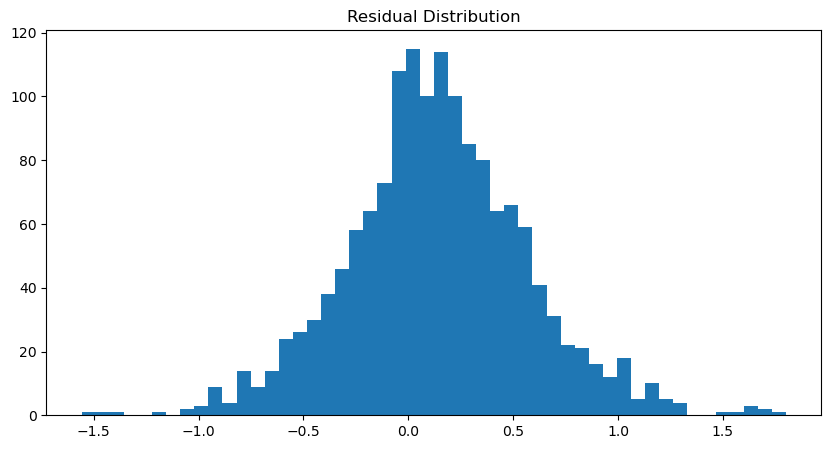

In [20]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=50)

plt.title("Residual Distribution")

plt.show()

Residuals are centered around zero, suggesting that the model does not exhibit strong systematic bias.  
However, the dispersion of residuals increases during high-volatility periods, indicating heteroskedastic errors, a common characteristic in financial time series.
  
We also examine residuals over time:

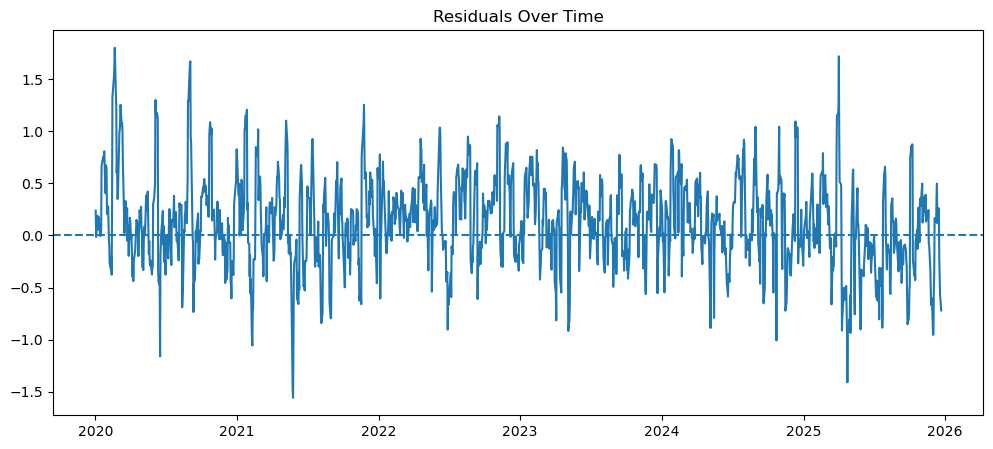

In [21]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, residuals)
plt.title("Residuals Over Time")
plt.axhline(0, linestyle="--")
plt.show()

Residuals fluctuate around zero, indicating that the model does not exhibit systematic bias.  
Error variance increases during periods of market stress, reflecting the inherent difficulty of predicting volatility during extreme events.  
This pattern is consistent with regime-dependent volatility dynamics observed in financial markets.


## 6.5 Stability Over Time

Average metrics can hide instability across market regimes.  
We therefore compute a rolling RMSE to evaluate model stability.

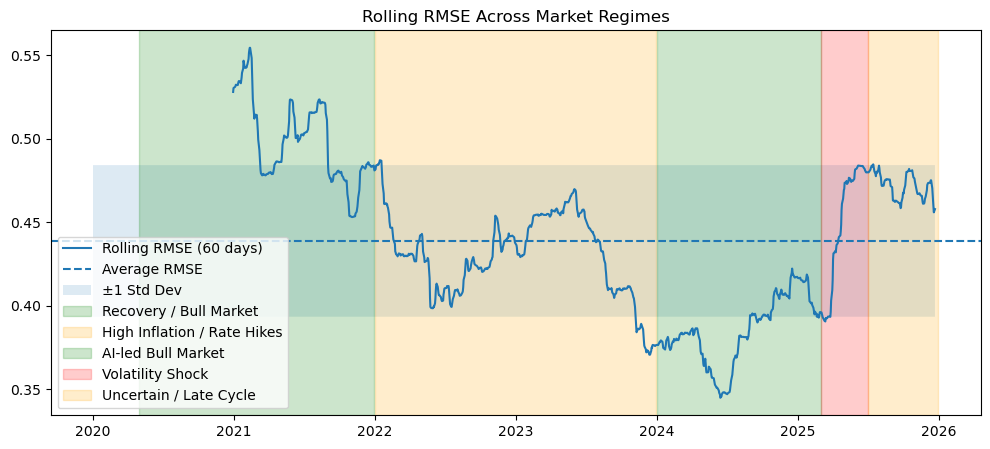

In [22]:
errors = (y_test - y_pred_test) ** 2

rolling_rmse = np.sqrt(errors.rolling(252).mean())

plt.figure(figsize=(12,5))

plt.plot(rolling_rmse, label="Rolling RMSE (60 days)")

# RMSE mean and standard deviation
mean_rmse = rolling_rmse.mean()
std_rmse  = rolling_rmse.std()

plt.axhline(mean_rmse, linestyle="--", label="Average RMSE")

plt.fill_between(
    rolling_rmse.index,
    mean_rmse - std_rmse,
    mean_rmse + std_rmse,
    alpha=0.15,
    label="±1 Std Dev"
)

# regimes
plt.axvspan("2020-05-01", "2021-12-31", color="green", alpha=0.20, label="Recovery / Bull Market")
plt.axvspan("2022-01-01", "2023-12-31", color="orange", alpha=0.20, label="High Inflation / Rate Hikes")
plt.axvspan("2024-01-01", "2025-03-01", color="green", alpha=0.20, label="AI-led Bull Market")
plt.axvspan("2025-03-01", "2025-07-01", color="red", alpha=0.20, label="Volatility Shock")
plt.axvspan("2025-07-01", "2025-12-31", color="orange", alpha=0.20, label="Uncertain / Late Cycle")

plt.title("Rolling RMSE Across Market Regimes")
plt.legend()

plt.savefig("../outputs/rolling_rmse.png", dpi=300, bbox_inches="tight")

plt.show()

The rolling RMSE remains relatively stable around its long-term average. Error spikes during volatility shocks, occasionally exceeding the typical variability band.  
This confirms that predictive performance is partly regime-dependent but remains broadly stable across market conditions.

## 6.6 Performance Across Volatility Regimes

Average performance metrics can hide important differences between market regimes.  
We therefore evaluate model performance separately during **high volatility** and **low volatility** periods.  
Volatility regimes are defined using the 75th and 25th percentiles of rolling volatility.

In [23]:
# Define volatility thresholds

df_model = joblib.load("../models/df_model.pkl")
threshold_high = df_model["vol_20"].quantile(0.75)
threshold_low  = df_model["vol_20"].quantile(0.25)

high_vol_idx = df_model.loc["2020":"2025"]["vol_20"] > threshold_high
low_vol_idx  = df_model.loc["2020":"2025"]["vol_20"] < threshold_low

# Predictions from best model
y_pred_test = best_model.predict(X_test_red)
pred_series = pd.Series(y_pred_test, index=y_test.index)

# Evaluate on high volatility periods
high_vol_metrics = evaluate_model(
    y_test[high_vol_idx],
    pred_series[high_vol_idx]
)

# Evaluate on low volatility periods
low_vol_metrics = evaluate_model(
    y_test[low_vol_idx],
    pred_series[low_vol_idx]
)

# Comparison table
regime_results = pd.DataFrame({
    "High Volatility": high_vol_metrics,
    "Low Volatility": low_vol_metrics
}).T

regime_results

,RMSE,MAE,R2
High Volatility,0.452700,0.337986,0.277402
Low Volatility,0.521523,0.405505,-0.127160


The model performs significantly better during high-volatility regimes, where volatility dynamics are stronger and easier to detect.  
During calm market periods, volatility becomes smaller and more stochastic, which reduces predictability and leads to lower explanatory power.

Overall, the evaluation confirms that the model captures key volatility dynamics such as clustering and regime shifts. 
While prediction accuracy decreases during calm periods, the model remains particularly informative during market stress, which is often the most relevant scenario for risk management applications.

# 7. Model Interpretability  
Understanding the drivers of predicted volatility is important for financial applications.
We therefore analyze both global feature importance and local model behavior using permutation importance and SHAP values.


## 7.1 Global Feature Importance

Permutation importance is used to identify the most influential predictors driving volatility forecasts.

We analyze:

• dominant volatility features  
• redundancy among predictors  
• sensitivity of the model to regime indicators  
  
Permutation importance measures how much model performance deteriorates when a feature is randomly shuffled. Features that cause larger performance drops are considered more important.

In [24]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on the test set
perm_importance = permutation_importance(
    best_model,
    X_test_red,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Convert to DataFrame
perm_df_final = pd.DataFrame({
    "feature": X_test_red.columns,
    "importance": perm_importance.importances_mean
})

perm_df_final = perm_df_final.sort_values("importance", ascending=False)

perm_df_final.head(15)

,feature,importance
3,vol_60,4.337616e-02
0,cond_vol_20,3.267432e-02
4,rolling_mean_return_5,2.360168e-02
7,rolling_mean_return_10,1.449346e-02
2,max_drawdown_20,1.312737e-02
5,vol_10,1.273978e-02
17,vol_ratio_5_60,3.207843e-03
9,rolling_mean_return_20,2.858302e-03
12,stress_score,2.343084e-03
15,volume_ratio_20,1.744431e-03


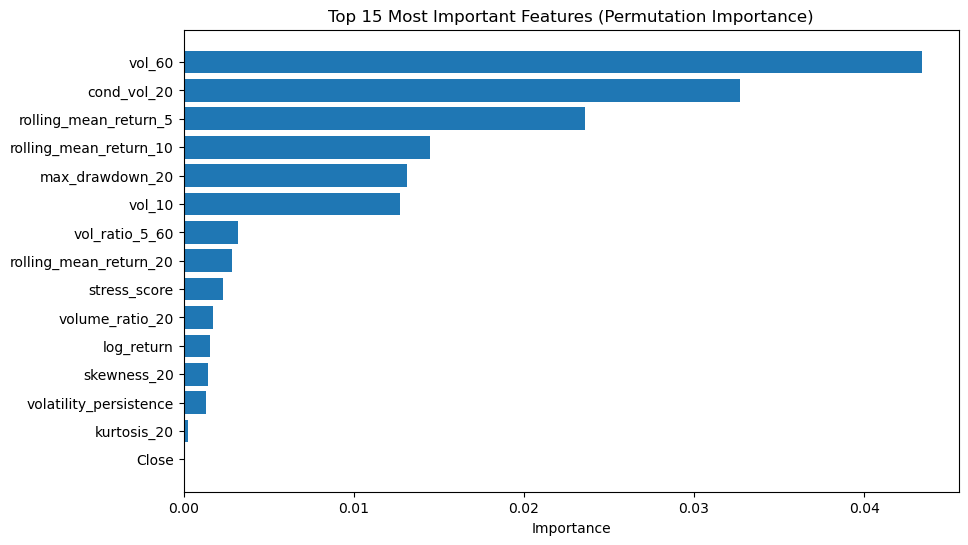

In [25]:
top_features = perm_df_final.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features (Permutation Importance)")
plt.xlabel("Importance")

plt.savefig("../outputs/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

Permutation importance highlights the dominant role of volatility-related indicators in the model’s predictions.

The most influential features include vol_60, cond_vol_20, and short-term return dynamics. This confirms the well-known volatility persistence observed in financial markets, where recent volatility levels strongly influence future volatility.

Market stress indicators such as max_drawdown_20 also contribute to the forecasts, while higher-order distribution features play a more limited role.

7.2 Local Model Behavior (SHAP)

SHAP values provide local interpretability, allowing us to understand how individual features contribute to specific predictions.

This helps reveal:

• non-linear feature effects  
• interaction patterns  
• regime-dependent feature contributions  

SHAP decomposes each prediction into additive contributions from individual features.

In [26]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


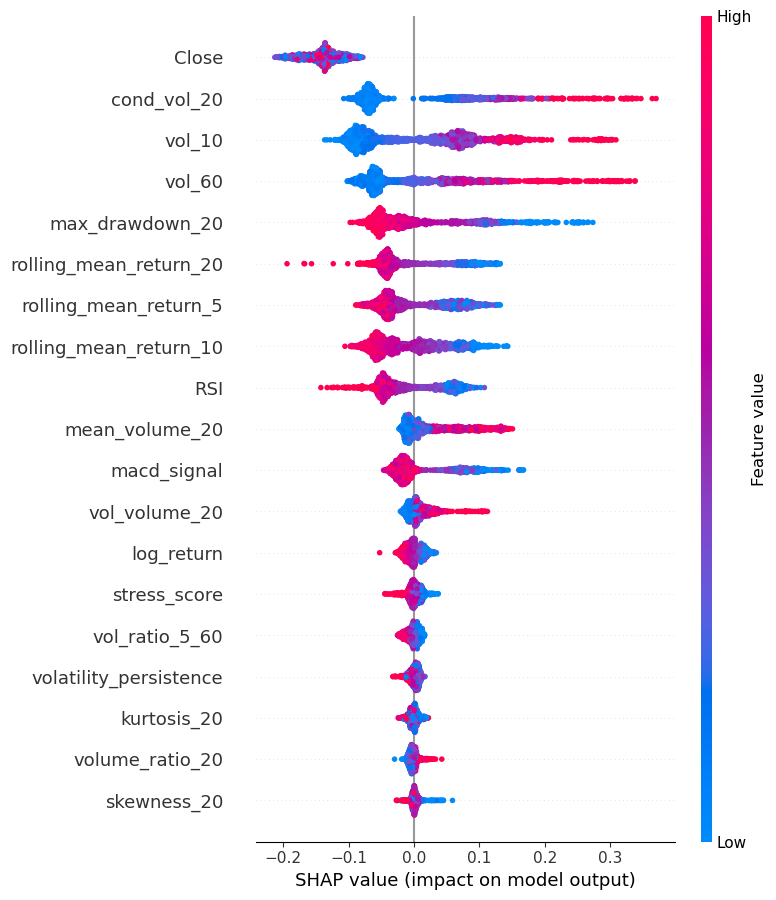

In [32]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on test data
shap_values = explainer.shap_values(X_test_red)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_red, show=False)

plt.savefig("../outputs/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

The SHAP summary plot confirms that volatility measures dominate the model’s predictions.  
Higher values of volatility indicators generally lead to higher predicted volatility, consistent with the phenomenon of volatility clustering in financial markets.  
Other predictors contribute less but help capture additional market dynamics.

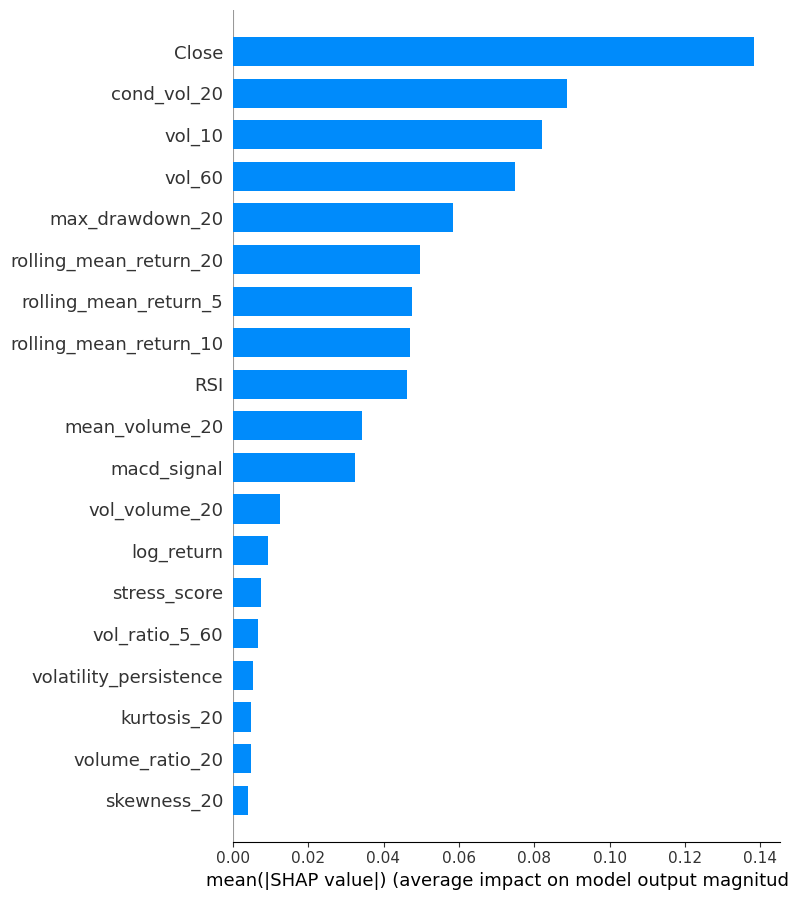

In [28]:
# SHAP Global Importance Plot
shap.summary_plot(
    shap_values,
    X_test_red,
    plot_type="bar"
)

The SHAP global importance ranking is broadly consistent with the permutation importance results.  
Volatility-related features remain the primary drivers of the model’s predictions, reinforcing the robustness of the interpretability results.

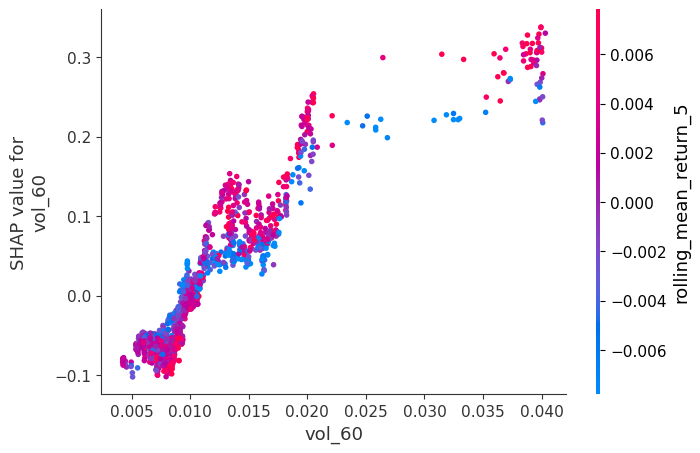

In [ ]:
# SHAP dependence plot for the most important feature
shap.dependence_plot(
    perm_df_final.iloc[0]["feature"],
    shap_values,
    X_test_red,
    show=False
)

plt.savefig("../outputs/shap_dependence_top_feature.png", dpi=300, bbox_inches="tight")

plt.show()

The SHAP dependence plot for vol_60 shows a clear positive relationship between recent volatility and the model’s predicted volatility.  
As volatility increases, the model assigns larger positive SHAP contributions, indicating a monotonic but mildly non-linear effect.
  

The interpretability analysis shows that the model primarily relies on recent volatility dynamics and persistence features to forecast future volatility.  
Both permutation importance and SHAP analysis consistently identify volatility indicators as the main drivers of predictions, in line with established financial theory.  
Overall, the model appears to capture economically meaningful relationships in volatility dynamics.

# 8. Financial Robustness

## 8.1 Regime Performance

Financial markets exhibit strong regime-dependent volatility dynamics.
To assess the robustness of the forecasting framework, we previously evaluated model performance across high- and low-volatility regimes.

The results indicate that prediction errors tend to increase during high-volatility periods, which is expected given the greater complexity of market dynamics during stress episodes.

However, overall performance remains relatively stable across regimes, suggesting that the model captures key drivers of volatility dynamics rather than overfitting to a specific market environment.

## 8.2 Risk-Based Evaluation

Volatility forecasts can be directly used in financial risk management frameworks to estimate potential portfolio losses.  
Two common risk measures derived from volatility forecasts are:
* **Value at Risk** (VaR): the maximum expected loss at a given confidence level
* **Expected Shortfall** (ES): the average loss beyond the VaR threshold  

Expected Shortfall is often preferred in modern risk management because it better captures tail risk during extreme market events.

In [30]:
import scipy.stats as stats

# predicted volatility
pred_vol = best_model.predict(X_test_red)

# confidence level
alpha = 0.95
z = stats.norm.ppf(alpha)

# VaR
var_95 = -z * pred_vol

# Expected Shortfall
es_95 = -(pred_vol * stats.norm.pdf(z) / (1 - alpha))

var_series = pd.Series(var_95, index=y_test.index)
es_series  = pd.Series(es_95, index=y_test.index)

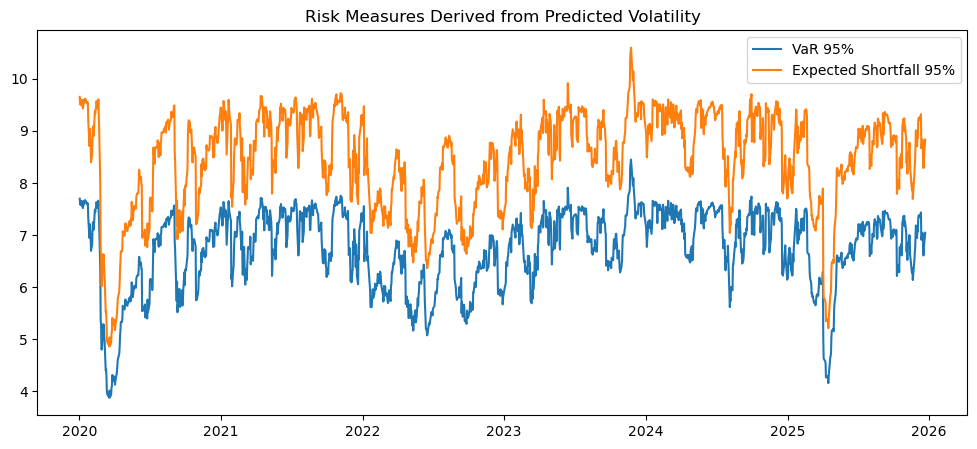

In [31]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, var_series, label="VaR 95%")
plt.plot(y_test.index, es_series, label="Expected Shortfall 95%")
plt.title("Risk Measures Derived from Predicted Volatility")
plt.legend()
plt.show()

Both VaR and Expected Shortfall increase during periods of elevated predicted volatility, reflecting higher potential losses during market stress.

Expected Shortfall consistently exceeds VaR, as it captures the average severity of losses beyond the VaR threshold, providing a more conservative estimate of tail risk.

# 9. Discussion
## 9.1 Model Performance

The results indicate that machine learning models improve volatility forecasting compared to linear baselines.

The tuned Random Forest model achieved the best predictive performance, suggesting that non-linear models capture important patterns in volatility dynamics that linear models cannot fully represent.

However, the performance improvement remains moderate, highlighting the inherent difficulty of forecasting financial volatility.

## 9.2 Bias–Variance Tradeoff

Linear models provide stable predictions but are limited by their inability to capture complex non-linear relationships.

Tree-based models introduce greater flexibility and improve predictive performance, but may also increase variance.
The tuned Random Forest provides a balanced compromise between model flexibility and stability.

## 9.3 Financial Interpretation

Interpretability analysis shows that the model relies primarily on recent volatility indicators and persistence effects, consistent with established financial theory on volatility clustering.

These results suggest that the model captures economically meaningful signals rather than relying on spurious correlations.

## 9.4 Limitations

Several limitations should be acknowledged.

First, the analysis focuses on a single market index, which may limit the generalizability of the results.

Second, financial markets are subject to structural breaks and regime shifts, which can affect model stability over time.

Finally, risk metrics derived from predicted volatility rely on simplifying assumptions regarding return distributions, and therefore provide only an approximate estimate of tail risk.

# 10. Conclusion
## 10.1 Summary of Results

This project explored the use of machine learning techniques to forecast financial market volatility.

The results show that tree-based models outperform linear baselines, with the tuned Random Forest achieving the best predictive performance. While the improvement remains moderate, it demonstrates the ability of non-linear models to capture complex patterns in volatility dynamics.

Interpretability analysis further confirms that the model relies primarily on recent volatility indicators and persistence effects, consistent with well-established properties of financial markets.

## 10.2 Future Work

Several extensions could further improve the forecasting framework.

First, incorporating macroeconomic variables or market-wide risk indicators could provide additional predictive signals.
Second, more advanced models such as regime-switching models or stochastic volatility approaches could better capture structural changes in volatility dynamics.

Finally, extending the framework to multiple assets or higher-frequency data could provide a richer understanding of volatility behavior across financial markets.